In [1]:
import sys
sys.executable

'C:\\Users\\justin\\Desktop\\Millerton\\millerton_reservoir\\.venv\\Scripts\\python.exe'

In [54]:
# %matplotlib ipympl

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from pathlib import Path

from pyqualw2.utils import jday_to_date
from pyqualw2.config import Config
from pyqualw2.config.inputs import FlowInput
from pyqualw2.model_runner import ModelRunner
from pyqualw2.outputs import QWO, QWOLayers, MultiRunResult, RunResult

In [90]:


data_path = Path("./model/")
inputs = data_path / "inputs"
historic = data_path / "historic_data"
TCD_Flows = historic / "TCD_flow_files"

output_dir_2022 = Path("analysis_runs/2026_TCD_Flows_2022")
output_dir_2024 = Path("analysis_runs/2026_TCD_Flows_2024")

temp_2022 = historic / "temp_data" / "SJA_2022_temp.csv"
temp_2024 = historic / "temp_data" / "SJA_2024_temp.csv"

config_TCD_22_flow = Config.from_files(
    name="22_TCD_Flow",
    con=data_path / "w2_con.csv",
    bathymetry=inputs / "mbth_wb1.csv",
    profile=inputs / "mvpr1.npt",
    met_data=historic / "met_data" / "2022_CEQUAL_met_inputs.csv",
    shade=inputs / "mshade.npt",
    temperature_tributaries=[inputs / "mtdt_br1.npt"],
    # See note about why this is 4 separate values, while the other branch-dependent arguments are not.
    temp_data=[temp_2022, temp_2022, temp_2022, temp_2022],
    flow_data= TCD_Flows / "2022" / "2022_TCD_Flow10.csv",
    wind_sheltering=inputs / "mwsc.npt",
    flow_data_date_col="Date",
    flow_data_inflow_cols=[["Date", "M_IN"]],
    flow_data_outflow_cols=[["Date", "SPL_OUT", "FKC_OUT", "MC_OUT", "SJR_OUT", "TCD_OUT"]],
    flow_data_evaporation_cols=[["Date", "MIL_EVAP"]],
)

config_TCD_24_flow = Config.from_files(
    name="24_TCD_Flow1",
    con=data_path / "w2_con.csv",
    bathymetry=inputs / "mbth_wb1.csv",
    profile=historic/ "temp_profiles" / "240315_profile.npt",
    met_data=historic / "met_data" / "2024_CEQUAL_met_inputs.csv",
    shade=inputs / "mshade.npt",
    temperature_tributaries=[inputs / "mtdt_br1.npt"],
    # See note about why this is 4 separate values, while the other branch-dependent arguments are not.
    temp_data=[temp_2024, temp_2024, temp_2024, temp_2024],
    flow_data= TCD_Flows / "2024" / "2024_TCD_Flow1.csv",
    wind_sheltering=inputs / "mwsc.npt",
    flow_data_date_col="Date",
    flow_data_inflow_cols=[["Date", "M_IN"]],
    flow_data_outflow_cols=[["Date", "SPL_OUT", "FKC_OUT", "MC_OUT", "SJR_OUT", "TCD_OUT"]],
    flow_data_evaporation_cols=[["Date", "MIL_EVAP"]],
)

In [91]:
#timedata can receive any ISO 8609-formatted datetime string
config_TCD_22_flow.con.timedata = ( '2022-03-10','2022-12-31', 1921)
config_TCD_22_flow.bathymetry.segment_data["ELWS [m]"] = 158.67

config_TCD_24_flow.con.timedata = ( '2024-03-15','2024-12-31', 1921)
config_TCD_24_flow.bathymetry.segment_data["ELWS [m]"] = 165.01

In [92]:
# Set all the flow to 0 for branches 2, 3, and 4. Then add three copies of this
# dummy data to serve as those dummy branches
dummy_flow_data = config_TCD_22_flow.branch_inflow[0].data.copy()
dummy_flow_data.iloc[:, 1] = 0
config_TCD_22_flow.branch_inflow.extend(
    [
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
    ]
)

# Set all the flow to 0 for branches 2, 3, and 4. Then add three copies of this
# dummy data to serve as those dummy branches
dummy_flow_data = config_TCD_24_flow.branch_inflow[0].data.copy()
dummy_flow_data.iloc[:, 1] = 0
config_TCD_24_flow.branch_inflow.extend(
    [
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
    ]
)


In [93]:
ModelRunner(config_TCD_24_flow, output_dir=output_dir_2024).run(overwrite=True)

In [94]:
base_run = RunResult("analysis_runs/2026_TCD_Flows_2024/24_TCD_Flow0_1")
base_mix = base_run.mixing_temperature(4,5)

compare_run = RunResult("analysis_runs/2026_TCD_Flows_2024/24_TCD_Flow1")
tcd_temp_mix = compare_run.mixing_temperature(4,5)

compare_run_2 = RunResult("analysis_runs/2026_TCD_Flows_2024/24_TCD_Flow4")
tcd_temp_mix_2 = compare_run_2.mixing_temperature(4,5)

compare_run_3 = RunResult("analysis_runs/2026_TCD_Flows_2024/24_TCD_Flow7")
tcd_temp_mix_3 = compare_run_3.mixing_temperature(4,5)

compare_run_4 = RunResult("analysis_runs/2026_TCD_Flows_2024/24_TCD_Flow10")
tcd_temp_mix_4 = compare_run_4.mixing_temperature(4,5)

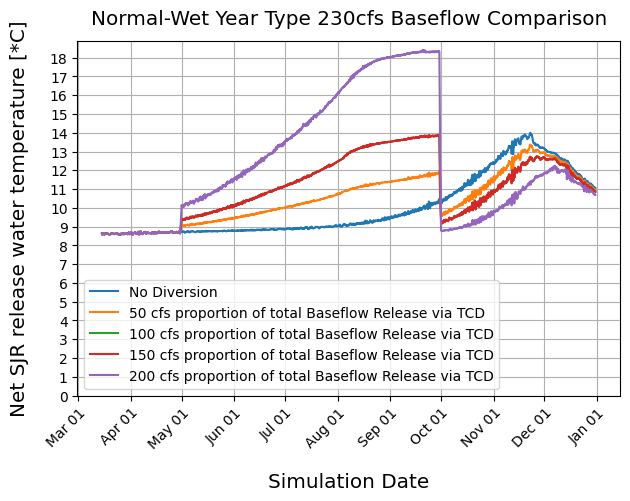

In [100]:

fig, ax = plt.subplots()
ax.plot(
    jday_to_date(base_mix["JDAY"]),
    base_mix["mixed_flow_temperature [C]"],
    label="No Diversion",
)
ax.plot(
    jday_to_date(tcd_temp_mix["JDAY"]),
    tcd_temp_mix["mixed_flow_temperature [C]"],
    label="50 cfs proportion of total Baseflow Release via TCD",
)
ax.plot(
    jday_to_date(tcd_temp_mix_2["JDAY"]),
    tcd_temp_mix_2["mixed_flow_temperature [C]"],
    label="100 cfs proportion of total Baseflow Release via TCD",
)
ax.plot(
    jday_to_date(tcd_temp_mix_3["JDAY"]),
    tcd_temp_mix_3["mixed_flow_temperature [C]"],
    label="150 cfs proportion of total Baseflow Release via TCD",
)
ax.plot(
    jday_to_date(tcd_temp_mix_4["JDAY"]),
    tcd_temp_mix_4["mixed_flow_temperature [C]"],
    label="200 cfs proportion of total Baseflow Release via TCD",
)

# Rotate the x-labels to make it so they don't overlap
xticks, labels = ax.get_xticks(), ax.get_xticklabels()
ax.set_xticks(xticks, labels=labels)
ax.set_xticks(xticks, labels=labels, rotation=45, ha="right", rotation_mode="anchor")

# Resize the axis labels
ax.set_ylabel(ax.get_ylabel(), fontsize="x-large", labelpad=15)
ax.set_xlabel(ax.get_xlabel(), fontsize="x-large", labelpad=15)

#Format x-axis labels to Month(short) and day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Set y-axis to start at zero
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# Set axis label
ax.set_ylabel("Net SJR release water temperature [*C]")

ax.set_xlabel("Simulation Date")

# Set grid to show
plt.grid()

# Add a legend to the plot
ax.legend(loc="best")

# Resize the figure to accommodate the changes to axis labels
plt.tight_layout()

ax.set_title("Normal-Wet Year Type 230cfs Baseflow Comparison", fontsize="x-large", pad=12)

plt.show()

In [7]:
met_para_list = [historic / "met_data" /"2022_CEQUAL_met_inputs.csv",
historic / "met_data" /"2023_CEQUAL_met_inputs.csv",
historic / "met_data" /"2024_CEQUAL_met_inputs.csv",
historic / "met_data" /"2021_CEQUAL_met_inputs.csv",
historic / "met_data" /"2020_CEQUAL_met_inputs.csv",
historic / "met_data" /"2019_CEQUAL_met_inputs.csv",
historic / "met_data" /"2018_CEQUAL_met_inputs.csv",
historic / "met_data" /"2017_CEQUAL_met_inputs.csv",
historic / "met_data" /"2016_CEQUAL_met_inputs.csv",
historic / "met_data" /"2015_CEQUAL_met_inputs.csv",
historic / "met_data" /"2014_CEQUAL_met_inputs.csv",]

flow_para_list = [TCD_Flows / year / "2022_TCD_Flow1.csv",
TCD_Flows / year / "2022_TCD_Flow2.csv",
TCD_Flows / year / "2022_TCD_Flow3.csv",
TCD_Flows / year / "2022_TCD_Flow4.csv",
TCD_Flows / year / "2022_TCD_Flow5.csv",
TCD_Flows / year / "2022_TCD_Flow6.csv",                 
TCD_Flows / year / "2022_TCD_Flow7.csv",
TCD_Flows / year / "2022_TCD_Flow8.csv",
TCD_Flows / year / "2022_TCD_Flow9.csv",
TCD_Flows / year / "2022_TCD_Flow10.csv",
TCD_Flows / year / "2022_TCD_Flow11.csv",
TCD_Flows / year / "2022_TCD_Flow12.csv",]
                  
configs_TCD = config_TCD_flow.parameterize({"met_data":met_para_list})


In [8]:
ModelRunner(configs_TCD, output_dir=output_dir_2022).run(overwrite=True, dry_run=True)

Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpowh89t97'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpfyvlqqrb'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmp01jduywd'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpboz9a5mu'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmp26t342mm'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpzgjcs_81'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpg1lculv0'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpib42k2mu'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpa7y_bto_'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmpght7b7h5'
Generated config at 'C:\\Users\\justin\\AppData\\Local\\Temp\\tmp3m2l0brd'


In [24]:
mrr_TCD_2022 = MultiRunResult("./analysis_runs/2026_TCD_Flows_2022/")

FileNotFoundError: [Errno 2] No such file or directory: 'analysis_runs/2026_TCD_Flows_2022/.ipynb_checkpoints/outputs'

## Comparison Plots

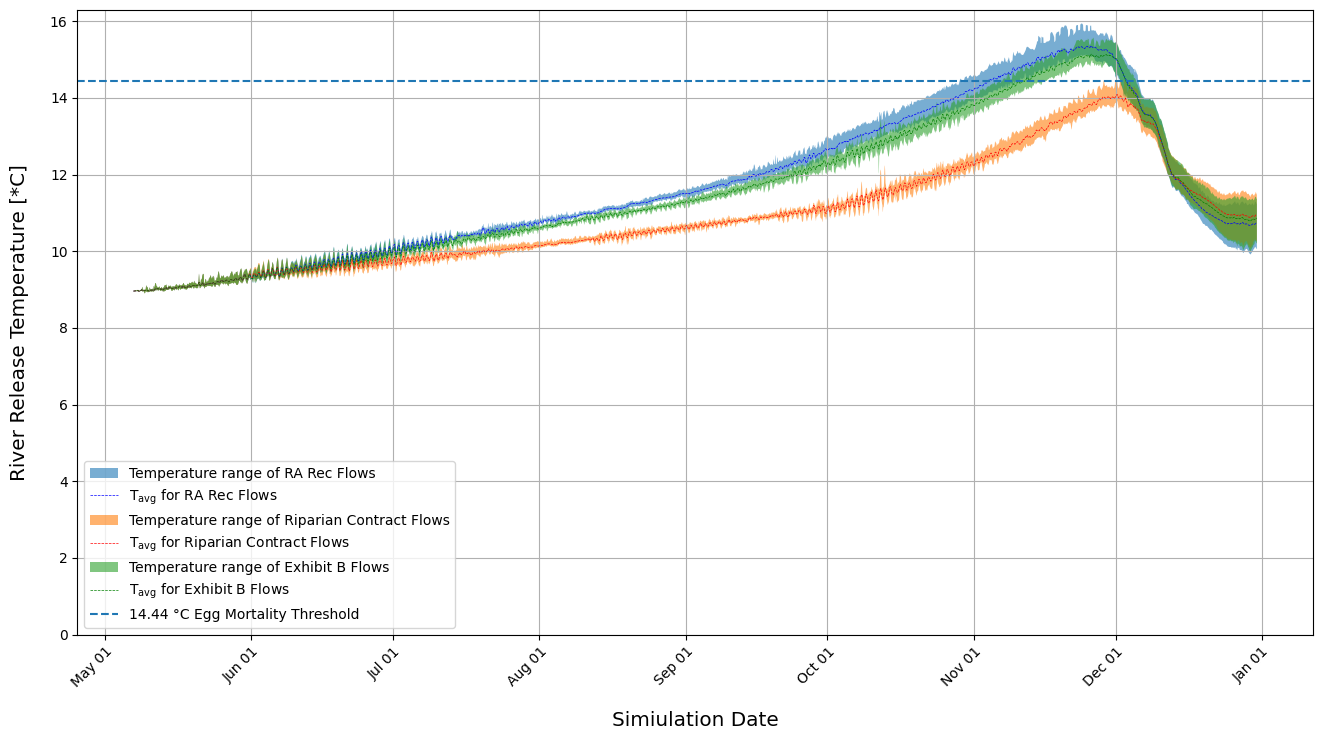

In [8]:

fig, ax = plt.subplots(1, 1, figsize=(13.33, 7.5))
_fig, _ax, RA_region, RA_line = mrr_RA.plot_two_structure_composite(4, ax=ax);
_fig, _ax, Rip_Con_region, Rip_Con_line = mrr_RipCon.plot_two_structure_composite(4, ax=ax);
_fig, _ax, ExB_region, ExB_line = mrr_ExB.plot_two_structure_composite(4, ax=ax);

# Modify the labels for the min/max region and average temperature line.
RA_region.set_label("Temperature range of RA Rec Flows")
RA_line.set_label(r"$\mathrm{T_{avg}}$ for RA Rec Flows")
RA_line.set_color("blue")
RA_line.set(linewidth=0.5)
RA_line.set_linestyle("--")

Rip_Con_region.set_label("Temperature range of Riparian Contract Flows")
Rip_Con_line.set_label(r"$\mathrm{T_{avg}}$ for Riparian Contract Flows")
Rip_Con_line.set_color("red")
Rip_Con_line.set(linewidth=0.5)
Rip_Con_line.set_linestyle("--")

ExB_region.set_label("Temperature range of Exhibit B Flows")
ExB_line.set_label(r"$\mathrm{T_{avg}}$ for Exhibit B Flows")
ExB_line.set_color("green")
ExB_line.set(linewidth=0.5)
ExB_line.set_linestyle("--")

# Draw the 14.44°C threshold line
mrr_RA.plot_threshold_line_y(ax, linestyle="--", label="14.44 °C Egg Mortality Threshold")

# Rotate the x-labels to make it so they don't overlap
xticks, labels = ax.get_xticks(), ax.get_xticklabels()
ax.set_xticks(xticks, labels=labels)
ax.set_xticks(xticks, labels=labels, rotation=45, ha="right", rotation_mode="anchor")

# Resize the axis labels
ax.set_ylabel(ax.get_ylabel(), fontsize="x-large", labelpad=15)
ax.set_xlabel(ax.get_xlabel(), fontsize="x-large", labelpad=15)

#Format x-axis labels to Month(short) and day
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Set y-axis to start at zero
ax.set_ylim(bottom=0)

# Set axis label
ax.set_ylabel("River Release Temperature [*C]")

ax.set_xlabel("Simiulation Date")

# Set grid to show
plt.grid()

# Add a legend to the plot
ax.legend(loc="best")

# Resize the figure to accommodate the changes to axis labels
plt.tight_layout()
fig.savefig("2026_ra_flow_comparison.svg")

plt.show()

## Threshold Summary Table

In [12]:
threshold_temperature = 14.44
structure = 4

exb_summary = mrr_ExB.threshold_summary(structure, threshold=threshold_temperature)
exb_summary["Restoration Flow Scenario"] = "ExB"

ra_summary = mrr_RA.threshold_summary(structure, threshold=threshold_temperature)
ra_summary["Restoration Flow Scenario"] = "RA"

ripcon_summary = mrr_RipCon.threshold_summary(structure, threshold=threshold_temperature)
ripcon_summary["Restoration Flow Scenario"] = "RipCon"

df = pd.concat([exb_summary, ra_summary, ripcon_summary])
df

,Tavg [C],Tmin [C],Tmax [C],Days above threshold,Restoration Flow Scenario
26_ExB_Flow_met2014,11.544073,8.95,15.37,22.913,ExB
26_ExB_Flow_met2015,11.414793,8.95,15.08,17.789,ExB
26_ExB_Flow_met2016,11.504663,8.94,15.25,21.955,ExB
26_ExB_Flow_met2017,11.474736,8.93,15.33,19.953,ExB
26_ExB_Flow_met2018,11.483200,8.95,15.22,20.916,ExB
26_ExB_Flow_met2019,11.459553,8.93,15.27,17.409,ExB
26_ExB_Flow_met2020,11.409527,8.94,14.99,17.743,ExB
26_ExB_Flow_met2021,11.602851,8.94,15.57,27.659,ExB
26_ExB_Flow_met2022,11.559415,8.90,15.22,24.832,ExB
26_ExB_Flow_met2023,11.468529,8.94,15.09,21.708,ExB
